In [1]:
import sys
import os
sys.path.append(os.pardir)

In [2]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

In [3]:
import matplotlib.pyplot as plt

In [4]:
#Modeling and Forecasting
import skforecast
import lightgbm
import sklearn
from lightgbm import LGBMRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import RFECV
from skforecast.recursive import ForecasterEquivalentDate, ForecasterRecursive
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import TimeSeriesFold, bayesian_search_forecaster, backtesting_forecaster
from skforecast.feature_selection import select_features
from skforecast.preprocessing import RollingFeatures
from skforecast.plot import calculate_lag_autocorrelation, plot_residuals
from skforecast.metrics import calculate_coverage

/Users/maxwellgriffith/miniconda3/envs/loadcast/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df = (pd.read_csv("../data/raw/loadtempday_clean.csv")
        .drop_duplicates()
        .pipe(lambda df: df.set_index(pd.to_datetime(df["date"])))
        .drop(columns = ["date"])
     )
#this will throw an error if there are duplicates
df.index = df.index.tz_localize(None)
df.index.freq = 'h'

In [6]:
df.head()

,Demand,Temperature,is_day
date,,,
2023-01-01 00:00:00,28291.0,11.3615,0
2023-01-01 01:00:00,28727.0,9.5615,0
2023-01-01 02:00:00,28370.0,7.9615,0
2023-01-01 03:00:00,27955.0,7.3115,0
2023-01-01 04:00:00,27668.0,6.2615,0


In [7]:
### Train Val Test Split
TRAIN_START = "2023-01-01 00:00:00"
TRAIN_END   = "2024-06-30 23:00:00"
VAL_START   = "2024-07-01 00:00:00"
VAL_END     = "2024-12-31 23:00:00"
TEST_START  = "2025-01-01 00:00:00"
TEST_END    = "2025-12-31 23:00:00"

In [8]:
data = df.copy()
data_train = data.loc[: TRAIN_END, :].copy()
data_val   = data.loc[VAL_START:VAL_END, :].copy()
data_test  = data.loc[TEST_START:, :].copy()

print(f"Train dates      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Validation dates : {data_val.index.min()} --- {data_val.index.max()}  (n={len(data_val)})")
print(f"Test dates       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Train dates      : 2023-01-01 00:00:00 --- 2024-06-30 23:00:00  (n=13128)
Validation dates : 2024-07-01 00:00:00 --- 2024-12-31 23:00:00  (n=4416)
Test dates       : 2025-01-01 00:00:00 --- 2025-12-31 23:00:00  (n=8760)


### Baseline Forecaster
- seasonal naive forecaster used to compare performance of future models
- trained and evaluated with backtesting
- predicts each hour using the value of the same hour on the previous day

In [ ]:
# Create baseline: value of the same hour of the previous day
forecaster = ForecasterEquivalentDate(
                 offset    = pd.DateOffset(days=1),
                 n_offsets = 1
             )

# Train forecaster
forecaster.fit(y=data.loc[:VAL_END, 'Demand'])

In [ ]:
# Create cross validation folds to test all models
cv = TimeSeriesFold(
        steps              = 24,
        initial_train_size = len(data.loc[:VAL_END]),
        refit              = False
)

In [11]:
#Base line forecaster evaluation
metric, predictions = backtesting_forecaster(
                          forecaster = forecaster,
                          y          = data['Demand'],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                       )
metric

100%|███████████████████████████████████████████████████████████| 365/365 [00:01<00:00, 283.56it/s]


,mean_absolute_error
0,1560.271233


### Recursive Multi-step forecast
- use gradient descent for the estimator (the enginge that solves the Ax = y matrix)
- forecaster handles creating the matrix from the time series
- will use 24 lags to predict the outcome
- basic auto regressive model

In [ ]:
# Create forecaster
forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
             )
forecaster.fit(y=data.loc[:VAL_END, 'Demand'])

In [13]:
#Back test auto-regressive model
ar_metric, ar_predictions = backtesting_forecaster(
                          forecaster    = forecaster,
                          y             = data['Demand'],
                          cv            = cv,
                          metric        = 'mean_absolute_error',
                          verbose       = False, # Set to False to avoid printing
                      )
ar_metric

100%|███████████████████████████████████████████████████████████| 365/365 [00:01<00:00, 344.99it/s]


,mean_absolute_error
0,1371.449927


In [14]:
# Add a three day moving average: Auto Regressive Moving Average model
#Create forecaster
window_features = RollingFeatures(stats=["mean"], window_sizes=24 * 3)
forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
                 window_features = window_features
             )

In [15]:
#Back test auto-regressive moving average model
arma_metric, arma_predictions = backtesting_forecaster(
                          forecaster    = forecaster,
                          y             = data['Demand'],
                          cv            = cv,
                          metric        = 'mean_absolute_error',
                          verbose       = False, # Set to False to avoid printing
                      )
arma_metric

100%|███████████████████████████████████████████████████████████| 365/365 [00:02<00:00, 164.16it/s]


,mean_absolute_error
0,1416.300394


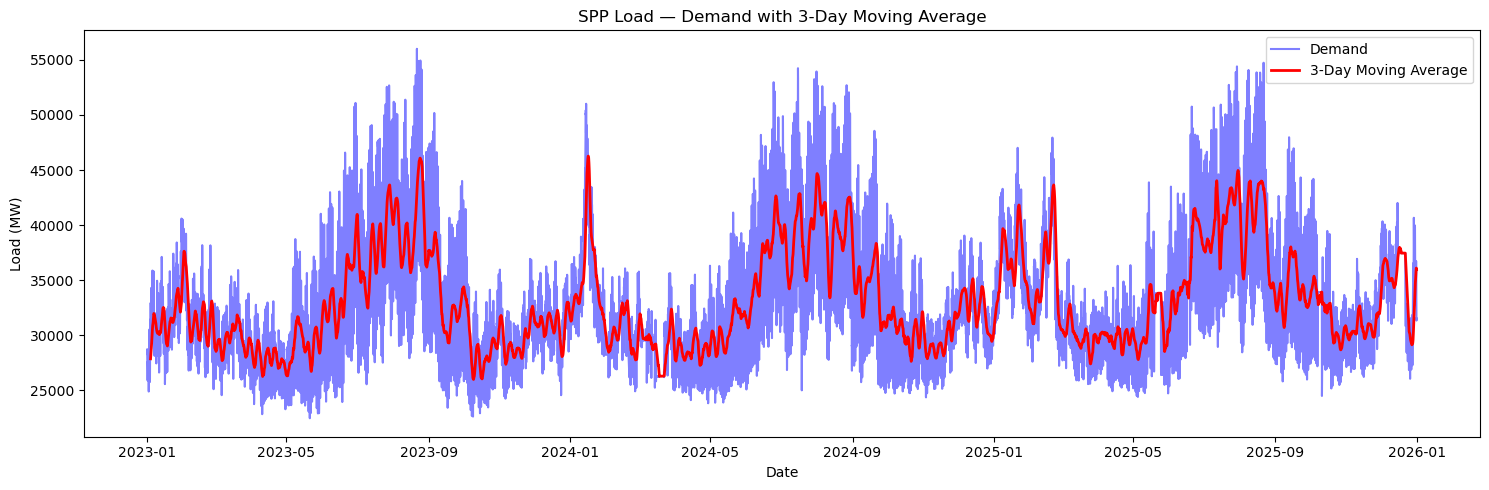

In [16]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df.index, df["Demand"], label="Demand", color="blue", alpha=0.5)
ax.plot(df.index, df["Demand"].rolling(window=72).mean(), label="3-Day Moving Average", color="red", linewidth=2)

ax.set_title("SPP Load — Demand with 3-Day Moving Average")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()

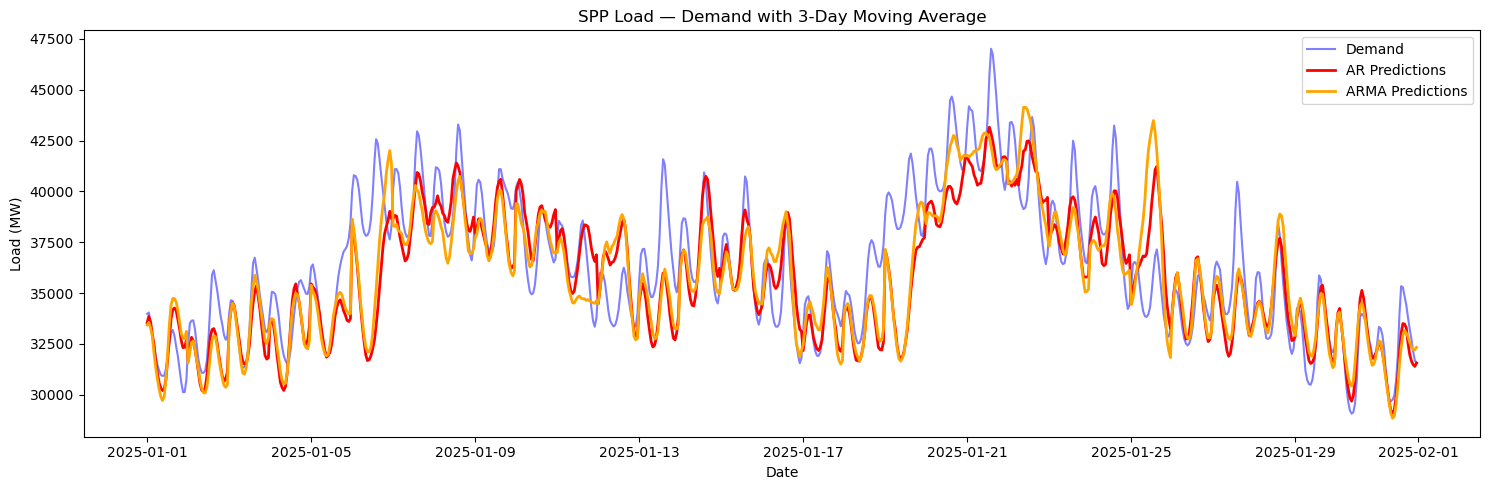

In [17]:
#graphic the actual values, the predicts from AR and ARMA
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(data_test.loc["2025-01"].index, data_test.loc["2025-01"]["Demand"], label="Demand", color="blue", alpha=0.5)
ax.plot(ar_predictions.loc["2025-01"].index, ar_predictions.loc["2025-01"]["pred"], label="AR Predictions", color="red", linewidth=2)
ax.plot(arma_predictions.loc["2025-01"].index, arma_predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="orange", linewidth=2)

ax.set_title("SPP Load — Demand with 3-Day Moving Average")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()

issue with big divergence with large increases/decreases in load. the prediction and actual are almost opposites of each other. This is a major flaw as large swings in load would be of greater importance when planning based on a forecast

### Exogenous Variables
- values of the exogenous variables must be known at the time of prediction.
- we will use temperature, daylight time, and calendar features

In [19]:
from features import set_holidays, cal_features, cyclic_features

In [47]:
exo_vars = (data
            .pipe(set_holidays)
            .pipe(cal_features)
            .pipe(cyclic_features)
            .assign(Holiday=lambda d: d["Holiday"].astype(int))
            .assign(Temp_3D_Mean=lambda d: d["Temperature"].rolling("3D", center = True).mean())
            .drop(columns = ["Demand"])
           )
# add a 1 day mean temperature mean?

In [ ]:
# temp rolling 3 day average
#df["Temperature"].rolling(window=72).mean()
# is doing it by days too big of a window? mabye we add an expoential component to weight it?
df.rolling("3D", center=True).mean() #mean(yesterday, today, tomorrow)

In [48]:
exo_vars.head()

,Temperature,is_day,Holiday,month,week,day_of_week,hour,month_sin,month_cos,week_sin,week_cos,day_sin,day_cos,hour_sin,hour_cos,Temp_3D_Mean
date,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,11.3615,0,0,1,52,6,0,0.5,0.866025,0.0,1.0,-0.781831,0.62349,0.000000,1.000000,6.769608
2023-01-01 01:00:00,9.5615,0,0,1,52,6,1,0.5,0.866025,0.0,1.0,-0.781831,0.62349,0.258819,0.965926,6.735184
2023-01-01 02:00:00,7.9615,0,0,1,52,6,2,0.5,0.866025,0.0,1.0,-0.781831,0.62349,0.500000,0.866025,6.698679
2023-01-01 03:00:00,7.3115,0,0,1,52,6,3,0.5,0.866025,0.0,1.0,-0.781831,0.62349,0.707107,0.707107,6.674000
2023-01-01 04:00:00,6.2615,0,0,1,52,6,4,0.5,0.866025,0.0,1.0,-0.781831,0.62349,0.866025,0.500000,6.659061


In [49]:
#Possible extension to polynomial features

### Feature Selection